In [13]:
import numpy as np
from sklearn.linear_model import lars_path, lasso_path

def sample(d, n, k, seed=0):
  # d >= k
  shape = (d, n)

  rng = np.random.default_rng(seed=seed)
  X = rng.standard_normal(shape)

  mask = rng.standard_normal(shape)
  m = np.sort(mask, axis=0)[k-1, :, np.newaxis]
  mask = ((mask - m.T) <= 0).astype(int)

  return X * mask

def normalize_columns(X): # normalize columns, avoiding division by 0
    n = np.linalg.norm(X, axis=0)

    return np.divide(X, n, where=(n>0), out=np.zeros_like(X))

def norm_mse(X, Y):

  Xn = normalize_columns(X)
  Yn = normalize_columns(Y)

  return (np.linalg.norm(Xn-Yn, axis=0)**2).mean()

def lasso_lars_oracle(Phi, y, oracle, topk=0):
  # y = sign(Phi @ oracle). oracle should also be normalized here
  _, _, coef_path = lars_path(Phi, y, method='lasso') # coef_path has dimension d x (# of alphas it tried)

  if topk > 0:
    coef_path = hard_threshold(coef_path.T, topk).T

  coef_path_n = normalize_columns(coef_path)
  
  C = ((coef_path_n - oracle[:, np.newaxis])**2).sum(axis=0)

  minx = np.argmin(C)

  if (n := np.linalg.norm(coef_path.T[minx])) > 0:
     y = coef_path.T[minx] / n
  else:
     y = coef_path.T[minx]

  return y  # return best x(alpha)

def lasso_lars_threshold(Phi, y, eps=0.577, topk=0):
  # eps = 1/sqrt(3) comes from II.B in B&B paper, eps \leq sqrt(M \Delta^2 / 12) where \Delta is the quantization interval
  # taking RMS divides by sqrt(M), so we get eps_rms = sqrt(\Delta ^2 / 12) = sqrt(4/12) = 1/sqrt(3)
  
  _, _, coef_path = lars_path(Phi, y, method='lasso') # coef_path has dimension d x (# of alphas it tried)

  if topk > 0:
    coef_path = hard_threshold(coef_path.T, topk).T

  rms = np.sqrt(((Phi @ coef_path - y[:, np.newaxis])**2).sum(axis=0) / Phi.shape[0])

  threshold = rms < eps

  threshold = np.array([])

  if np.flatnonzero(threshold).size > 0:
    ix = np.argmax(threshold)
  else:
    ix = np.argmin(rms)

  if (n := np.linalg.norm(coef_path.T[ix])) > 0:
     y = coef_path.T[ix] / n
  else:
     y = coef_path.T[ix]

  return y # return first x(alpha) where the residual |Phi coef_path[:, i] - y| < eps

def hard_threshold(x, k):
  if x.shape[-1] <= k:
    return x.copy()

  abs_x = np.abs(x)
  # partition gives the k-th largest value per row
  threshold = np.partition(abs_x, -k, axis=-1)[..., -k:]
  cutoff = threshold[..., :1]  # shape (..., 1) for broadcasting

  return np.where(abs_x >= cutoff, x, 0.0)

In [14]:
def l1_prox(x, v):
  return np.sign(x) * np.maximum(np.abs(x) - v, 0)

def renormalized_fpc_(Phi, Phi_pinv, y, Phi_n, init=None, sparse_proj=0, prox=True):

  gamma = 0.999
  xtol = 1e-6
  gtol = 0.2

  d = 2.0 / Phi_n

  #Y = np.diag(y)
  #A = (Y @ Phi).T

  if init == None:
    undersampling_ratio = Phi.shape[1] / y.shape[0]
    if (abs(1 - undersampling_ratio) < 0.1): # initialize with the transpose if the matrix is near-square, since the condition number is high in that case
      x = Phi.T @ y
    else:
      x = Phi_pinv @ y # otherwise initialize to Phi^+ y, recommended in the paper

    x /= np.linalg.norm(x)
  elif init == 'lasso':
    x = lasso_lars_threshold(Phi, y)

  #l = d / (gamma * np.max(np.abs(x))) #
  l = 0.02
  c = 2

  k = 0
  out_max = 50
  in_max = 100

  js = []

  while(k < out_max):
    x_outer_prev = x.copy()
    j = 0

    while(j < in_max):
      j += 1
      m = 0
      xprev = x.copy()

      # the paper writes Y = diag(y), the matrix with y down its diagonal. then Y x just flips the signs of x according to the entries of y.
      # but since the entries of y are just +1 or -1 we can write Y x as y * x (elementwise), so we can avoid forming the dense Y matrix. then the gradient
      # (Y Phi)^T f(Y Phi x) = Phi^T Y f'(y * (Phi x)) = Phi^T (y * f'(y * (Phi x)))
      # then f' is just the gradient of the one-sided quadratic penalty, so f'(x) = min(x, 0), and we get the expression below

      tmp = y * (Phi @ x) 
      gF = Phi.T @ (y * np.minimum(tmp, 0))

      gF = gF - np.dot(gF, x) * x # subtract radial component 

      h = x - (d) * gF # gradient descent

      z = h
      if prox:
        z = l1_prox(h, d/l)                   # apply the proximal operator

      zn = np.linalg.norm(z) # check if the new solution has norm 0. if so we skip and make mu bigger so it does less shrinking

      if zn == 0:
        # j += 1
        # mu *= B

        break
        
      if sparse_proj > 0:
        abs_z = np.abs(z)
        threshold = np.partition(np.abs(z), -sparse_proj, axis=0)[-sparse_proj]  # value of the k-th largest
        
        z = np.where(abs_z >= threshold, z, 0.0)

      x = z / zn # normalize

      if (np.abs(1 - (x.T @ xprev)) < xtol): # break inner loop when |1 - <x^k, x^{k+1}>| is small
        break

    # if (np.abs(1 - (x.T @ x_outer_prev)) < xtol): # break inner loop when |1 - <x^k, x^{k+1}>| is small
    #   m += 1
    #   if m > 4:
    #     break
    # else:
    #   m = 0

    #if(np.linalg.norm(x-x_outer_prev) < xtol):# and abs(mu * np.max(np.abs(x)) - 1.0 < gtol)): # break outer loop if the solution is stationary and the condition on the infinity norm of x holds
      #break

    k += 1
    l *= c
    js.append(j)

  #print(f"outer:{k}/{out_max}\ninner:" + "".join([f"{i}/{in_max}, " for k, i in enumerate(js)]))

  return x

def renormalized_fpc(Phi, Y, init='default', sparse_proj=0, prox=True):

  Phi_n = np.linalg.norm(Phi, ord=2)**2

  Phi_pinv = np.linalg.pinv(Phi)
  Xh = np.zeros((Phi.shape[1], Y.shape[1]))

  for i in range(Y.shape[1]):
    Xh[:, i] = renormalized_fpc_(Phi, Phi_pinv, Y[:, i], Phi_n=Phi_n, init=init, sparse_proj=sparse_proj, prox=prox)

  return Xh

def classical_cs(X, Phi, Y, threshold=0):
  X_n = X / np.linalg.norm(X, axis=0, keepdims=True)
  Xh = np.zeros_like(X)

  for i in range(Y.shape[1]):
    x = lasso_lars_threshold(Phi, Y[:, i], topk=threshold)  
    
    Xh[:, i] = x

  return Xh

def classical_cs_oracle(X, Phi, Y, threshold=0):

  Y = np.sign(Phi @ X)
  X_n = X / np.linalg.norm(X, axis=0, keepdims=True)
  Xh = np.zeros_like(X)

  for i in range(Y.shape[1]):
    x = lasso_lars_oracle(Phi, Y[:, i], X_n[:, i], topk=threshold)

    Xh[:, i] = x

  return Xh

def sparse_sphere_proj(x, k, threshold=1e-3):
  abs_x = np.abs(x)
  threshold = np.partition(np.abs(x), -k, axis=0)[-k]  # value of the k-th largest
  
  x_s = np.where(abs_x >= threshold, x, 0.0)
  
  return (x_s / np.linalg.norm(x_s, ord=2))

def biht_(Phi, y, k, M, max_iters):
  eta = np.sqrt(2*np.pi)

  x = Phi.T @ y

  for _ in range(max_iters):
    x = x + (eta / M) * Phi.T @ ((1 / 2) * (y - np.sign(Phi @ x)))

    x = sparse_sphere_proj(x, k)

  return x

def biht(X, Phi, Y, k):
  M = Phi.shape[0]

  max_iters = 25

  Y = np.sign(Phi @ X)
  Xh = np.zeros_like(X)

  for i in range(Y.shape[1]):
    x = biht_(Phi, Y[:, i], k, M, max_iters)

    Xh[:, i] = x

  return Xh


In [ ]:
import time
import matplotlib.pyplot as plt

def fit_sample( 
  n = 10,
  d = 512,
  k = 16,
  Ms = [50, 100, 200, 500, 1000, 2000, 3000],
  threshold = 0,
  seed=0):

  X = sample(d, n, k)

  mse_rfpc, mse_lars, mse_biht, t_rfpc, t_lars = [], [], [], [], []

  for M in Ms:
    rng = np.random.default_rng(seed)
    Phi = rng.standard_normal((M, d)) #/ np.sqrt(M)

    Y = np.sign(Phi @ X)

    u0 = time.perf_counter()
    Xh1 = classical_cs(X, Phi, Y, threshold=k)
    u = time.perf_counter() - u0

    t0 = time.perf_counter()
    Xh = renormalized_fpc(Phi, Y, init=None, sparse_proj=k)
    t = time.perf_counter() - t0

    u0 = time.perf_counter()
    Xh2 = biht(X, Phi, Y, k)
    u = time.perf_counter() - u0

    print(f"M={M} done")

    mse_rfpc += [10*np.log10(norm_mse(X, Xh))]
    mse_lars += [10*np.log10(norm_mse(X, Xh1))]
    mse_biht += [10*np.log10(norm_mse(X, Xh2))]

    t_rfpc += [t]
    t_lars += [u]

    #print(f"M={M}\nfpc:\n MSE={10*np.log10(norm_mse(X, Xh))}dB")
    #print(f" duration={t:.2f}s")

    #print(f"classical:\n MSE={10*np.log10(norm_mse(X, Xh1))}dB")
    #print(f" duration={u:.2f}s")

    #print("\n")
    
  return Xh, Xh1, Xh2, mse_rfpc, mse_lars, mse_biht

Ms = [50, 100, 200, 500, 1000, 2000, 3000]  
#Ms = [100, 500, 1000, 3000]  
k = 16
d = 512
n = 10
threshold = k

Xh, Xh1, Xh2, mse_rfpc, mse_lars, mse_biht = fit_sample(n, d, k, Ms=Ms, threshold=threshold)


M=50 done
M=100 done
M=200 done
M=500 done
M=1000 done
M=2000 done
M=3000 done


rpfc avg sparsity: 64.0
lasso-lars avg sparsity: 64.0
biht avg sparsity: 64.0


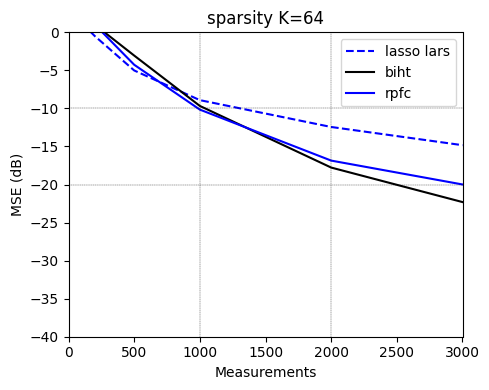

In [12]:
def plot_cs_comparison(m_values, mse_classical, mse_1bit, mse_oracle=None):
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(m_values, mse_classical, 'b--', label='lasso lars')
    ax.plot(m_values, mse_biht, 'k-', label='biht')
    ax.plot(m_values, mse_1bit, 'b-', label='rpfc')
    
    ax.set_xlabel('Measurements')
    ax.set_ylabel('MSE (dB)')
    ax.set_title(f'sparsity K={k}')
    ax.legend()
    ax.set_xlim(0, 3000)
    ax.set_ylim(-40, 0)
    ax.axvline(1000, color='k', linestyle='--', linewidth=0.25)
    ax.axvline(2000, color='k', linestyle='--', linewidth=0.25)
    ax.axhline(-10, color='k', linestyle='--', linewidth=0.25)
    ax.axhline(-20, color='k', linestyle='--', linewidth=0.25)
    plt.tight_layout()
    plt.show()

tol = 1e-3

print(f"rpfc avg sparsity: {np.mean(np.sum(np.abs(Xh) > tol, axis=0))}")
print(f"lasso-lars avg sparsity: {np.mean(np.sum(np.abs(Xh1) > tol, axis=0))}")
print(f"biht avg sparsity: {np.mean(np.sum(np.abs(Xh2) > tol, axis=0))}")

plot_cs_comparison(Ms, mse_lars, mse_rfpc, mse_oracle=None)

In [ ]:
def fit_rfpc_variants(
  n = 10,
  d = 512,
  k = 16,
  Ms = [50, 100, 200, 500, 1000, 2000, 3000],
  seed=0):

  X = sample(d, n, k)
  mse_both, mse_hard, mse_soft = [], [], []

  for M in Ms:
    rng = np.random.default_rng(seed)
    Phi = rng.standard_normal((M, d))
    Y = np.sign(Phi @ X)

    Xh_both = renormalized_fpc(Phi, Y, init=None, sparse_proj=k, prox=True)
    Xh_hard = renormalized_fpc(Phi, Y, init=None, sparse_proj=k, prox=False)
    Xh_soft = renormalized_fpc(Phi, Y, init=None, sparse_proj=0, prox=True)

    print(f"k={k}, M={M} done")

    mse_both += [10*np.log10(norm_mse(X, Xh_both))]
    mse_hard += [10*np.log10(norm_mse(X, Xh_hard))]
    mse_soft += [10*np.log10(norm_mse(X, Xh_soft))]

  return mse_both, mse_hard, mse_soft


def plot_rfpc_variant_comparison(m_values, mse_both, mse_hard, mse_soft, k, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))

    ax.plot(m_values, mse_both, 'b-', label='both')
    ax.plot(m_values, mse_hard, color='tab:orange', label='hard threshold only')
    ax.plot(m_values, mse_soft, color='tab:green', label='soft threshold only')

    ax.set_xlabel('Measurements')
    ax.set_ylabel('MSE (dB)')
    ax.set_title(f'sparsity K={k}')
    ax.legend()
    ax.set_xlim(0, 3000)
    ax.set_ylim(-40, 0)
    ax.axvline(1000, color='k', linestyle='--', linewidth=0.25)
    ax.axvline(2000, color='k', linestyle='--', linewidth=0.25)
    ax.axhline(-10, color='k', linestyle='--', linewidth=0.25)
    ax.axhline(-20, color='k', linestyle='--', linewidth=0.25)

    return ax


fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, k_value in zip(axes, [16, 32]):
  mse_both, mse_hard, mse_soft = fit_rfpc_variants(n=n, d=d, k=k_value, Ms=Ms)
  plot_rfpc_variant_comparison(Ms, mse_both, mse_hard, mse_soft, k_value, ax=ax)

axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

In [ ]:
\documentclass{article}
\usepackage{graphicx} 
\usepackage[margin=1in]{geometry}
\usepackage{amsmath}
\usepackage{amsfonts}
\usepackage{bbm}
\usepackage{float}
\usepackage{mathrsfs}
\usepackage{mathtools}
\usepackage{amssymb}
\usepackage{scalerel}
\usepackage{subcaption}
\usepackage{appendix}
\usepackage{algorithm}
\usepackage{algpseudocode}
\usepackage{amsthm}
\usepackage{}
\newtheorem{theorem}{Theorem}
\newtheorem{definition}{Definition}
\newtheorem{lemma}{Lemma}

\newcommand{\dd}{\mathrm{d}}
\newcommand{\x}{\mathbf{x}}
\newcommand{\xh}{\hat{\mathbf{x}}}
\newcommand{\y}{\mathbf{y}}
\newcommand{\n}{\textbf{n}}
\newcommand{\sign}{\operatorname{sign}}

\title{Algorithms For Compressed Sensing With 1-Bit Measurements}
\author{Zachary Dorson}
\date{May 2026}

\begin{document}

\maketitle

\begin{abstract}
Compressive sensing deals with the recovery of a sparse signal $\mathbf{x}\in \mathbb{R}^n$ from some collection of $M$ linear measurements $\varphi^T \mathbf{x}$, usually with $n\gg M$. One-bit compressive sensing refers to the case where our measurements are quantized to only one bit, i.e. we are given only $\operatorname{sign}(\varphi^T \mathbf{x})$. After introducing the basic concepts and giving some motivation for the 1-bit case, we discuss two algorithms[b\&b] [biht] that address this situation, their advantages over the classical treatment, and our attempts to replicate their results.
\end{abstract}

\pagebreak

\section{Introduction}
We begin by recounting the usual compressive sensing setting. Let $\x\in \mathbb{R}^n$ be a $k$-sparse vector, and $\Phi \in \mathbb{R}^{M \times n}$ for some $M \in \mathbb{N}$. Write $\varphi_i$ for the $i$'th row of $\Phi$. Now let $\y=\Phi \x$ be the vector of measurements $\varphi_i^T\x$. Compressive sensing tries to reconstruct $\x$ with $\y$ as input data. That is, we consider the problem
$$\min_{\hat{\mathbf{x}}} \|\hat{\mathbf{x}}\|_0 \quad \text{s.t.} \quad \Phi \hat{\mathbf{x}} = \mathbf{y}$$
where the $0$-norm counts the number of nonzero entries. This norm is difficult to optimize over, so we relax this problem to 
$$\min_{\hat{\mathbf{x}}} \|\hat{\mathbf{x}}\|_1 \quad \text{s.t.} \quad \Phi \hat{\mathbf{x}} = \mathbf{y}$$
simply replacing the $0$-norm with the $1$-norm. Of course, given $M \geq n$ we can always solve this problem, but by utilizing the sparsity of $\x$ we can show that reconstruction is possible when $M$ is less than $n$, with appropriate choice of $\Phi$. In particular, it has been shown that the amount of measurements needed scales logarithmically with the dimension $n$ as long as $\x$ is sparse and $\Phi$ has i.i.d Gaussian entries. More precisely, we ask that $M=O(k\log \frac{n}{k})$. \\

Consider a situation where one has some measurement device recording $\Phi \x$, and wishes to reconstruct $\x$. The theoretical treatment considers $\Phi \x$ as real-valued, but since we must capture and store this in finite time we know that we could never guarantee infinite precision. For instance, the \verb|float| type in C gives $6$-$7$ digits of precision. We can think of this as a form of rounding; we only know our measurements to the nearest $10^{-7}$'th. Indeed, any measurement or storage process introduces this imprecision, which we call quantization. MORE?? \\

We will consider the most extreme form of quantization, where we discard all but the sign of the measurement. That is, $\y=\operatorname{sign}(\Phi \x)$. Since this leaves exactly two possibilities for each measurement, $-1$ or $1$, we call this one-bit quantization. Recovery from these extremely quantized measurements is a very attractive proposition in many settings, for instance if we have strong constraints on storage or bandwidth. Further, a one-bit measurement can be thought of as a comparator to $0$, so the measurements themselves may also be much cheaper to capture. \\

Here we mention a geometric interpretation of this problem. Thinking of each row $\varphi_i$ of $\Phi$ as the normal vector to a hyperplane, the sign of the dot product $\varphi_i^T \x$ tells us only which side of that hyperplane $\x$ lies on. In particular, since we assume $\x$ is on the sphere, we can think of each measurement as determining a plane that sections the sphere. 

In this paper we will give more motivation for the one-bit case, discussing specific settings where it has been explored. We will then discuss two compressive sensing algorithms created to address the one-bit case; renormalized fixed-point iteration (RFPI), introduced in 2008[b\&b], and binary iterative hard thresholding (BIHT)[biht]. We will talk about their convergence, giving insights into the proofs, if applicable. We also present the results of our implementation of these algorithms applied to synthetic sparse signals. \\

\section{Related Work}

Much of the motivation for the one-bit setting comes from a practical place. As discussed earlier, one-bit measurements are cheaper to capture and cheaper to store, so we see a lot of interest in these methods in settings where we have strong hardware constraints. One such case is for wireless sensor networks (WSNs), which are networks of many cheap wireless sensors. In [https://arxiv.org/pdf/1401.1307] the authors develop a variant of BIHT to recover the signal when the measurement matrix $\Phi$ is unknown, called blind BIHT.  \\

In this project we focus on two algorithms, but more have been proposed for this setting. [survey] puts these algorithms in 3 categories: regularizer-based, penalty-class algorithms, and Bayesian frameworks. Regularizer-based algorithms, such as the RFPI algorithm we will discuss, add a regularization term $f(\xh)$ to the standard CS problem (2). Penalty-class algorithms minimize the $p$-norm of the sign violations, i.e.

$$\xh = \min_\x \Vert \min(\operatorname{diag}(y)\Phi \x, 0)\Vert^p_q \quad \text{s.t.} \quad \Vert \x\Vert_2=1, \;\x ^c=0,\; \Vert\x\Vert_0=k$$
where $\x^c$ are the indices of $\x$ that are outside the support. The BIHT algorithm we discuss is an example of a penalty-class algorithm. Finally, Bayesian compressed sensing frameworks were introduced to address noisy measurements, where we may have a sign flipped by the noise. \\

For this project we chose RPFC because it was the first proposed algorithm for this setting, and BIHT because it has strong convergence results. Additionally, choosing two algorithms of different classes gives a broader perspective. 


\section{Algorithms}

\subsection{Classical Treatment of Quantization}
Classically, we treat compressive sensing with quantized measurements as compressive sensing with noisy measurements. That is, we write 
$$\y = \Phi \x + n$$
for some noise $\n$. This noise then has a bound on its magnitude as a function of the length of the quantization interval, i.e. the distance between possible quantized values, or the accuracy of quantization. In particular, writing $\Delta$ for the accuracy of quantization, we have
$$\Vert \n \Vert _2=\bigr(\sum_i \Vert n_i \Vert^2\bigl)^\frac{1}{2}\leq C=\sqrt{\frac{M\Delta^2}{12}}$$

Then it was shown in [https://arxiv.org/pdf/math/0503066] that we can reconstruct $\x$ by solving the problem

$$\xh = \min_\x \Vert \x \Vert_1 \quad \text{s.t.} \quad \Vert \y - \Phi \x \Vert_2 \leq C$$

We may also relax this and solve the unconstrained problem 

$$\xh = \min_\x \Vert \x \Vert_1 +\tfrac \lambda 2 \Vert \y - \Phi \x \Vert_2^2$$

In the case of the C \verb|float| datatype our quantization intervals have length $\Delta =10^{-7}$, so the noise has very small magnitude. However, in the one-bit case this is not so nice. If $x \in \mathbb{R}$ then the quantization $\operatorname{sign}(x)$ would represent noise with unbounded magnitude. Of course, we expect any reasonable measurements to be mostly bounded, so there may still be a way to determine a reasonable quantization accuracy for the one-bit case. But, as was found by [b\&b], we can benefit from reformulating the problem in a way more natural to this form of quantization. 

\subsection{Renormalized Fixed-point Iteration}

Now we will discuss the first of the two algorithms considered in this paper. Renormalized Fixed-point Iteration was introduced in 2008 by Boufounos and Baraniuk[b\&b], and was the first algorithm developed for the one-bit case. First, note that since one-bit quantization is unchanged after multiplying the signal by a positive scalar, we could not hope to recover information about the magnitude of $\x$. Accordingly, we will assume $\x\in S^{n-1}\subset \mathbb{R}^n$ and require the same of our solution, so $\Vert \hat{\x}\Vert_2=1$. Then our goal in reconstruction is 
$$ \operatorname{sign}(\varphi_i^T \hat{\x}) = \y_i$$ 
or in matrix notation

$$ \sign(\Phi \xh)=\y$$

\pagebreak

Since $\sign(a)\sign(b)$ is 1 when $a$ and $b$ have the same sign and $-1$ when they have opposite signs, we may reformulate the above as an element-wise inequality 
$$\operatorname{diag}(y)\Phi \hat{\mathbf{x}} \geq 0$$
Then we take our $\ell_1$-relaxed classical CS problem (2) and write it with the sign constraint and norm constraint, giving

$$
\hat{\mathbf{x}}
=
\arg\min_{\mathbf{x}} \|\mathbf{x}\|_1
\quad
\text{s.t.}
\;
\operatorname{diag}(y)\Phi \mathbf{x} \geq 0,
\;
\|\mathbf{x}\|_2 = 1
$$
Now we would like to relax this sign constraint. [b\&b] define an objective function

$$f(x) = \begin{cases} \,\dfrac{x^2}{2} & \text{if } x < 0 \\[6pt] \;\;0 & \text{otherwise} \end{cases}$$
and relax the sign constraint of the above problem with $f$ to get
$$
\hat{\mathbf{x}}
=
\arg\min_{\mathbf{x}}
\|\mathbf{x}\|_1
+
\lambda \sum_i f\!\left((\operatorname{diag}(y)\Phi \mathbf{x})_i\right),
\qquad
\|\mathbf{x}\|_2 = 1
$$
This is a quadratic penalty on signs that do not match our measurements $\y$, scaled by the parameter $\lambda$. Then let

$$G(\xh)=\|\xh\|_1
+
\lambda \sum_i f\!\left((\operatorname{diag}(y)\Phi \xh)_i\right)$$ 

Now we have a cost function $G$ of the form $\Vert \xh \Vert_1 + \lambda F(\xh)$, which is the sum of a convex but non-smooth function and a smooth function, so we may look to a proximal gradient method, namely the fixed-point continuation algorithm. In particular, in [fpc] the authors show that an $\xh$ that minimizes $G$ also satisfies the fixed-point equation $$\x^*=S_{\frac{\delta}{\lambda}}(\x^*-\delta \nabla F(\x^*))$$

Where $\delta$ is the step size, $\lambda$ is the regularization parameter, and $S_\alpha(\x)$ is the element-wise soft thresholding operator

$$S_{\alpha}(\x)=\sign(\x)\odot\max(|\x|-\alpha, 0)$$
which we obtain as the proximal operator of the $\ell_1$ norm. So, the algorithm computes the gradient of the smooth part and does a gradient descent step, and then composes this with the soft thresholding operator, repeating until convergence. Additionally, [b\&b] introduces two modifications to address the one-bit case. In particular, they both address our norm constraint. Firstly, we modify the gradient descent step to only move $\xh$ along the component of the gradient tangent to the sphere. Explicitly, rather than using the raw gradient $f^{(t)}=\nabla F(\hat{x})$ we compute 

$$\bar{f}^{(t)}=f^{(t)}-\langle\hat{\x}^{(t-1)}, \; f^{(t)}\rangle \hat{\x}^{(t-1)}$$

Then our gradient descent step becomes $\xh^{(t)}=\xh^{(t-1)}-\delta \bar{f}^{(t)}$. Since $\xh$ is already normalized we can write the radial part of the gradient as $\langle\hat{\x}^{(t-1)}, \; f^{(t)}\rangle \hat{\x}^{(t-1)}$, so we simply subtract that component. While this alone does not guarantee that each $\xh$ will be on the sphere, it does mean that each step will be, to first-order, along the sphere. Secondly, after applying the proximal operator of the convex part, we divide $\xh$ by its norm to project onto the sphere. Let $\delta, \; \lambda$ be the step size and a shrinkage parameter, respectively, and write $\mathbf{Y}=\text{diag}(\y)$. Now we present the RFPC algorithm: \\

\begin{algorithm}[H]
\caption{Renormalized Fixed-point Iteration (RFPI)}
\begin{algorithmic}[1]
\For{$t = 1,2,3,\ldots$ until convergence}
    \State $\bar{\mathbf{f}}_t \gets (\mathbf{Y}\Phi)^T \bar{f}'(\mathbf{Y}\Phi \hat{\mathbf{x}}_{t-1})$
    \State $\tilde{\mathbf{f}}_t \gets \bar{\mathbf{f}}_t - \langle \bar{\mathbf{f}}_t,\hat{\mathbf{x}}_{t-1}\rangle \hat{\mathbf{x}}_{t-1}$
    \State $\mathbf{h} \gets \hat{\mathbf{x}}_{t-1} - \delta \tilde{\mathbf{f}}_t$
    \State $\mathbf{u} \gets \operatorname{sign}(\mathbf{h})\,
    \max\left\{|\mathbf{h}| - \frac{\delta}{\lambda},\,0\right\}$
    \State $\hat{\mathbf{x}}_t \gets \frac{\mathbf{u}}{\|\mathbf{u}\|_2}$
\EndFor

\end{algorithmic}
\end{algorithm}

where $\bar{f}'(x)$ is the derivative $f(x)'$ applied elementwise. In particular, from the definition of $f$ the gradient is just $x$ if $x<0$ and $0$ otherwise, so it's just $\min(x, 0)$. Then the chain rule gives the outer $(\mathbf{Y}\Phi)^T$ term. We compute the gradient, subtract the radial component, and do the gradient descent step. Then we apply the soft thresholding operator with cutoff $\frac{\delta}{\lambda}$ and normalize the result. However, the authors note an issue: we cannot know the correct value of $\lambda$ a priori. It must be large enough so that the sign constraint is penalized sufficiently, but if it is too large then the soft thresholding step is not effective enough. The proposed solution is to wrap this in an outer algorithm, increasing $\lambda$ each iteration until convergence. Explicitly, we have the following:

\begin{algorithm}[H]
\caption{RFPI with continuation}
\begin{algorithmic}[1]
\State Set continuation parameters $\lambda_0$, $\beta$
\State $\hat{\mathbf{x}}^{(0)} \sim S^{n-1}$
\For{$i = 1,2,3,\ldots$ until convergence}
    \State $\lambda_i \gets \lambda_0 \cdot \beta^{i-1}$
    \State $\hat{\mathbf{x}}^{(i)} \gets$ result of RFPI with starting point $\hat{\mathbf{x}}^{(i-1)}$ and $\lambda=\lambda_i$
\EndFor
\end{algorithmic}
\end{algorithm}

We start with some $\xh^{(0)}$ satisfying our norm constraints, and some initial $\lambda_0$. Then we run RFPI on the current iterate $\xh^{(t)}$ until convergence, increasing $\lambda$ by a factor of $\beta>1$ each iteration. 


\subsection{Binary Iterative Hard Thresholding}
We again assume $\Vert \x\Vert_2=\Vert \hat{\x}\Vert_2=1$, for the same reasons as stated for RFPC. This algorithm optimizes a new objective, given by $J(\xh)=\Vert\operatorname{min}(0, \sign(\y)\odot \sign(\Phi \xh))\Vert_1$. Then we can write the subgradient of $J$ as 
$$\nabla J(\xh)\ni\Phi^T \tfrac 1 2 (\y-\sign(\Phi \xh))$$
We look at a slightly modified version of the BIHT algorithm, which was introduced in its unmodified form in [merl jacques] in 2013. In the original formulation each iteration of the algorithm does a subgradient descent step 
$$\xh^{(t)}=\xh^{(t-1)}-\alpha\nabla J(\xh^{(t-1)})$$
and then hard thresholds the output, repeating until convergence. Then we normalize onto the unit sphere, but only after convergence. The version we consider adds a normalization each iteration, so we can think of the algorithm as being comprised of a subgradient descent step and then projection onto the set of $k$-sparse vectors on the unit sphere. Let $\Sigma_k^n$ be the set of $k$-sparse vectors in $\mathbb{R}$, and $\eta$ be the step size. Then we have the BIHT algorithm:


\begin{algorithm}[H]
\caption{Binary iterative hard thresholding (BIHT)}
\begin{algorithmic}[1]
\State $\hat{\mathbf{x}}^{(0)} \sim S^{n-1} \cap \Sigma_k^n$
\For{$t = 1,2,3,\ldots$}
    \State $\tilde{\mathbf{x}}^{(t)}
    \gets \hat{\mathbf{x}}^{(t-1)}
    + \frac{\eta}{M}\Phi^T \cdot \frac{1}{2}
    \left(
    \mathbf{y}
    - \operatorname{sign}(\Phi\hat{\mathbf{x}}^{(t-1)})
    \right)$
    \State $\tilde{\mathbf{x}}^{(t)}
    \gets
    \text{Proj}_{\Sigma_k^n} (\tilde{\mathbf{x}}^{(t)})$
    \State $\hat{\mathbf{x}}^{(t)}
    \gets
    \frac{\tilde{\mathbf{x}}^{(t)}}{\Vert \tilde{\mathbf{x}}^{(t)}\Vert_2}$
\EndFor
\end{algorithmic}
\end{algorithm}

Since this has no continuation schedule, it is much simpler than the full RFPI algorithm. It also has convergence guarantees that RFPI cannot provide, as we discuss in the next section. 

\subsection{Convergence of RFPI and BIHT}
As noted in [b\&b], the RFPI algorithm is not guaranteed to converge to the true signal $\x$, and may get stuck at a local extrema. This is because the optimization is done on the unit sphere, which is not a convex set. However, in the case of BIHT it was shown that we converge to an $\epsilon$-ball around the true solution. In classical CS we introduce the restricted isometry property (RIP) to show convergence, and the authors of [biht] introduce a property serving a similar purpose, which they call the restricted approximate invertibility condition (RAIC). In particular, for the classical result it is shown that Gaussian matrices have the RIP with a high probability, and the authors use that same strategy with the RAIC. We give more details in the appendix. Now we present an informal version of the convergence theorem given in [biht].

\begin{theorem}[Matsumoto, Mazumdar]
Let $x \in S^{n-1}$ be $k$-sparse, and let $\Phi \in \mathbb{R}^{M \times n}$ have i.i.d.\ Gaussian rows. For any $\epsilon > 0$, if
\[
    M = O\!\left(\frac{k}{\epsilon}
        \log \frac{n}{k\sqrt{\epsilon}}\right),
\]
then with high probability the BIHT iterates satisfy
\[
    d_{S^{n-1}}\!\left(x, \hat{x}^{(t)}\right)
    \leq 2^{2^{-t}}\epsilon^{1-2^{-t}},
    \qquad t = 0,1,2,\ldots
\]
\end{theorem}

We suppress a much larger expression for the order of $M$, and instead give the statement the authors presented as the informal version. 

\pagebreak

\section{Results}

\begin{figure}[H]
    \centering
    % Top row: k16 and k32 side by side
    \begin{subfigure}[t]{0.4\textwidth}
        \centering
        \includegraphics[width=\textwidth]{k16.png}
        \caption{$k=16$}
    \end{subfigure}
    \hfill
    \begin{subfigure}[t]{0.4\textwidth}
        \centering
        \includegraphics[width=\textwidth]{k32.png}
        \caption{$k=32$}
    \end{subfigure}
    
    \vspace{1em}
    
    % Bottom: k64 centered
    \begin{subfigure}[t]{0.4\textwidth}
        \centering
        \includegraphics[width=\textwidth]{k64.png}
        \caption{$k=64$}
    \end{subfigure}
    \caption{Reconstruction performance for baseline, RFPI$^*$, BIHT}
\end{figure}

\begin{figure}[H]
    \centering
    \includegraphics[width=1\linewidth]{rfpc variants.png}
    \caption{Performance of variations of RFPI}
    \label{fig:placeholder}
\end{figure}

We plot the results of our implementations of the previously discussed algorithms on synthetic signals. In particular, we generate vectors $\x \in \mathbb{R}^{512}$ with uniform random support of size $K=16,32$, and populate the support with i.i.d Gaussian entries. The classical baseline curve is LASSO-LARS. We choose the lars solution with lowest RMSE from the data. We generate a Gaussian measurement matrix $\Phi$ for each $M$ which is used in all algorithms, along with the input data $\y$. We do 10 trials at each $M$, plotting the average of the reconstruction error. We give an asterisk to the RFPI curve because we used the variant with both hard thresholding and soft thresholding, not the version presented in (3.2). \\

\section{Discussion}
For low $M$ we did not see large benefits from the one-bit specific algorithms, even seeing the classical baseline performing better for very low values of $M$. However, as $M$ increases we start to see much better reconstruction accuracy from RFPI than the classical baseline, and even better performance from BIHT. While the usual compressive sensing regime has $n \gg M$, for the one-bit case it is more reasonable to have a large number of measurements, since we have much less information per measurement. Accordingly, we see that RFPC and BIHT benefit more from large numbers of one-bit measurements while the classical baseline levels off much sooner. \\

The second graph shows the performance of three variants of RFPC. The green curve labeled 'soft threshold only' is the algorithm implemented exactly as written above, while the other two curves add a hard thresholding step before normalization. The orange curve shows the result of replacing the soft thresholding step with hard thresholding, while the blue curve shows the result of hard thresholding the output of the soft thresholding operator before normalization. Without the addition of a hard thresholding step we were unable to replicate the results of [b\&b], and got reconstruction error that is comparable to the classical baseline, but the addition of the hard thresholding gives a large improvement to the reconstruction. The small difference between the blue and orange curves is expected, as the hard thresholding and soft thresholding are both serving a similar purpose, so their composition should not have any dramatic effects. From these results it seems plausible that we could replicate the success of the hard thresholding with just the soft thresholding by choosing the appropriate $\lambda$ and $\beta$, but we were not able to find a pair that gave significantly better reconstructions. 


\section{Conclusion}
One-bit compressive sensing is of interest in many cases, in particular when our hardware is constrained such that reducing energy/bandwidth usage leads to large cost reductions. We find that these one-bit specific algorithms do indeed give benefits in this setting, in particular when we have large amounts of measurements. 


\pagebreak
\appendix
\section{Appendix}

Here we give more details on the RAIC property and convergence proof of BIHT discussed in (3.3). First, let $$h_\Phi (\x, \y)=\frac{\eta}{M}\Phi^T \cdot \frac{1}{2}
    \left(
    \sign(\Phi \x)
    - \operatorname{sign}(\Phi\y)
    \right)$$
and 
$$ h_{\Phi; J}(\x, \y)=\text{Proj}_{\text{supp}(\x)\cup\text{supp}(\y)\cup J}(h_\Phi(\x, \y))$$
The first expression is exactly the subgradient of the BIHT objective that we discussed in (3.3), up to a scalar multiple. In particular, we have 
$$\tfrac {M}{\eta}h_\Phi(\x, \xh) \in \nabla J$$
Then we have the definition of the RAIC

\begin{definition}[Restricted Approximate Invertibility Condition]{Let $\delta, a_1, a_2>0$ and $k,M,n\in \mathbb{Z}^+$ so that $0<k<n$. The $(k,n,\delta,a_1,a_2)$-RAIC is satisfied by a matrix $\Phi \in \mathbb{R}^{M \times n}$ if}
$$\Vert (\x-\y) - h_{\Phi;J}(\x, \y)\Vert_2 \leq a_1 \sqrt{\delta d_{S^{n-1}}(\x, \y)}+a_2\delta$$
is satisfied uniformly for all $k$-sparse $\x,\y\in \mathbb{R}^n$ and all index sets $J\in [n]$, $|J|\leq k$.
\end{definition}

Note that $d_{S^{n-1}}(\x,\y)$ is just $\Vert\frac{\x}{\Vert \x\Vert_2} - \frac{\y}{\Vert \y \Vert_2}\Vert_2$, the distance between $\x$ and $\y$ after they have been projected onto the sphere. In the case of BIHT, where $\x$ is the signal and $\y=\xh$, this gives us a bound on the difference between $(\x - \xh)$ and the subgradient term $h_{\Phi;J}(\x, \xh)$. That is, this guarantees that our gradient descent step is moving us in the right direction, since if the difference were $0$ that step would become $\xh - (\x - \xh)=\x$, and we would recover $\x$. Next we present a lemma.

\begin{lemma}{Consider any $k$-sparse $\x \in S^{n-1}$ and any $t\in \mathbb{Z}^+$. The error of the $t$'th approximation produced by the BIHT algorithm satisfies}

$$d_{S^{n-1}}(\x, \xh^{(t)})\leq4\Vert (\x - \xh^{(t-1)}-h_{\Phi; \text{supp}(\xh^{(t)}}(\x, \xh^{(t-1)})\Vert_2$$
\end{lemma}
Now assume $\Phi$ satisfies the RAIC. Letting $e_t=d_{S^{n-1}}(\x^{(t)}-\x^{(t-1)})$, the above lemma gives 
\[
e_t
\leq
C\|(x-\hat x^{(t-1)})
-
h_{\Phi;J}(x,\hat x^{(t-1)})\|_2
\]
Applying the RAIC gives a recurrence relation
\[
e_t \leq C_1\sqrt{\delta e_{t-1}}+C_2\delta
\]
Now choose \(\delta\) proportional to the target accuracy \(\epsilon\). Then this becomes
\[
e_t \lesssim \sqrt{\epsilon e_{t-1}}+\epsilon .
\]
Since \(e_0\leq 2\), the diameter of the unit sphere, induction gives
\[
e_t \leq 2^{2^{-t}}\epsilon^{1-2^{-t}},
\]
up to universal constants. Hence the BIHT iterates rapidly converge to an
\(\epsilon\)-ball around the true signal $\x$.

\end{document}
